# Experimento 1: PubMedBERT — Resumen completo de resultados

**Modelo:** `microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext`
**Tarea:** Relation Extraction sobre NEREL-BIO (BioNNE-R track inglés)
**Baseline de referencia:** Macro F1 = 0.6944

---

## Todos los entrenos realizados en este notebook

### Entreno A — 20 epochs desde cero (este notebook, run actual)
- **Config:** lr=2e-5, batch=16, warmup=300, neg_ratio=3:1
- **Mejor epoch:** E11 → micro F1 = 0.8238
- **Macro F1 final (checkpoint E11):** 0.7718
- **Tiempo:** 141 minutos
- **Checkpoint guardado:** `eng_pubmedbert.pth.tar` (pesos de E11)
- **Observación:** curva oscilatoria a partir de E3, no monótona. Plateau claro desde E11.

### Entreno B — 10 epochs extra sobre E11 (sección 1b, misma sesión)
- **Config:** lr=1e-5, warmup=100, parte del checkpoint E11 del entreno A
- **Mejor epoch:** E6 de continuación → micro F1 = 0.8138
- **Macro F1 final:** 0.7574
- **Tiempo:** 71 minutos
- **Checkpoint guardado:** `eng_pubmedbert_continued.pth.tar`
- **Observación:** empeora respecto al entreno A. El modelo ya había convergido.

### Referencia — Exp1 original (run anterior, 10 epochs)
- **Config:** misma que entreno A pero EPOCHS=10
- **Mejor epoch:** E9 → micro F1 = 0.8243 (aún subiendo al cortar)
- **Macro F1 final:** 0.7754
- **Observación:** curva monótona, se cortó antes de converger.

---

## Comparativa

| Entreno | Epochs | Mejor epoch | Micro F1 best | Macro F1 | ¿Guardar? |
|---|---|---|---|---|---|
| Exp1 original (10ep) | 10 | E9 | 0.8243 | 0.7754 | Superado |
| **Entreno A (20ep)** | 20 | **E11** | **0.8238** | **0.7718** | ✅ **Este** |
| Entreno B (continuación) | +10 | E6 cont. | 0.8138 | 0.7574 | No |

**Checkpoint definitivo de este experimento: `eng_pubmedbert.pth.tar` (pesos de E11, entreno A).**
Micro F1=0.8238, Macro F1=0.7718.

El Exp1 original (0.7754) era ligeramente mejor en macro F1 por diferencia de scheduler,
pero no disponemos del checkpoint. El entreno A es el mejor disponible.

---

## Conclusión sobre epochs para futuros experimentos

PubMedBERT con `lr=2e-5` converge alrededor de **epoch 10-12** en todas las configuraciones probadas:
- Exp1 original: plateau habría llegado en ~E11 (cortamos en E9)
- Entreno A (20ep): plateau en E11 ✓
- Exp2 (typed markers): plateau en E11 ✓
- Exp3 (neg_ratio 1:1): plateau en E10 ✓

**Regla para experimentos futuros con PubMedBERT: usar 12 epochs.**
Suficiente margen sobre el plateau, sin desperdiciar GPU (~84 min con T4).

## 1. Setup e Instalacion

In [1]:
# Ejecutar solo la primera vez o en Colab
!pip install git+https://github.com/thunlp/OpenNRE.git
!pip install torch transformers nltk pandas scikit-learn matplotlib seaborn
!python ../baseline/patch_opennre.py

  Cloning https://github.com/thunlp/OpenNRE.git to /tmp/pip-req-build-rl1pl05x
  Running command git clone --filter=blob:none --quiet https://github.com/thunlp/OpenNRE.git /tmp/pip-req-build-rl1pl05x
  Resolved https://github.com/thunlp/OpenNRE.git to commit 8e42fd712f2ab01b48a7e7c4cb2bdea45ec6ff9a
  Preparing metadata (setup.py) ... done
  Created wheel for open-nre: filename=open_nre-0.1.1-py3-none-any.whl size=42022 sha256=e406f2746263de75b202f9f97f88d28902179209b5d64bfed22d4dfc7d11ed5e
  Stored in directory: /tmp/pip-ephem-wheel-cache-awvqvq4a/wheels/ea/ef/3b/4c1a3b1e8f2c5bdbe5961c073dd67f822110066ee2a43bb635
Successfully built open-nre
python3: can't open file '/kaggle/working/../baseline/patch_opennre.py': [Errno 2] No such file or directory


In [2]:
import json
import random
import re
import time
import logging
import os
from collections import Counter, defaultdict
from pathlib import Path

import nltk
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suprimir logs verbosos
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import opennre

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Configuracion del Experimento

Aqui defines todos los parametros. Para comparar con el baseline, solo cambiamos `MODEL_NAME`.

In [3]:
# ============================================================
# CONFIGURACION - Cambia aqui para probar diferentes modelos
# ============================================================

# Modelo a usar (CAMBIAR AQUI para probar otros)
MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
EXPERIMENT_NAME = "pubmedbert"  # nombre corto para archivos de salida

# Alternativas para probar despues:
# MODEL_NAME = "bert-base-multilingual-cased"    ; EXPERIMENT_NAME = "baseline"
# MODEL_NAME = "dmis-lab/biobert-v1.1"           ; EXPERIMENT_NAME = "biobert"
# MODEL_NAME = "allenai/scibert_scivocab_uncased" ; EXPERIMENT_NAME = "scibert"

# HIPERPARÁMETROS
MAX_LENGTH = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5  # Con este LR, plateau llega en epoch ~11.
EPOCHS = 15  # Cambiado de 20 a 15: suficiente margen sobre el plateau (~E11) sin desperdiciar GPU.
WARMUP_STEPS = 300
LANG = "english"
SEED = 42
NEG_RATIO = 3

# Paths Kaggle
DATA_DIR = Path("/kaggle/input/datasets/lucaespernjj/bionner-data")
TRAIN_DATA = DATA_DIR / "eng_train.txt"
DEV_DATA = DATA_DIR / "eng_dev.txt"
REL2ID_PATH = DATA_DIR / "rel2id.json"

# Outputs
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUTPUT_DIR / f"eng_{EXPERIMENT_NAME}.pth.tar"
PRED_PATH = OUTPUT_DIR / f"eng_pred_{EXPERIMENT_NAME}.tsv"

RELATION_TYPES = [
    "ABBREVIATION", "ALTERNATIVE_NAME", "SUBCLASS_OF", "PART_OF",
    "TREATED_USING", "ORIGINS_FROM", "TO_DETECT_OR_STUDY", "AFFECTS",
    "HAS_CAUSE", "APPLIED_TO", "USED_IN", "ASSOCIATED_WITH",
    "PHYSIOLOGY_OF", "FINDING_OF",
    "no_relation",
]

print(f"Experimento: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Clases: {len(RELATION_TYPES)} (14 relaciones + no_relation)")
print(f"\nDatos de entrenamiento: {TRAIN_DATA}")
print(f"Datos de dev: {DEV_DATA}")

Experimento: pubmedbert
Modelo: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Checkpoint: /kaggle/working/outputs/eng_pubmedbert.pth.tar
Clases: 15 (14 relaciones + no_relation)

Datos de entrenamiento: /kaggle/input/datasets/lucaespernjj/bionner-data/eng_train.txt
Datos de dev: /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt


## 3. Verificar Datos

Comprobamos que los datos preparados existen y estan bien.

In [4]:
!ls /kaggle/input/
!find /kaggle/input -iname "eng_train.txt"


datasets
/kaggle/input/datasets/lucaespernjj/bionner-data/eng_train.txt


In [5]:
# Verificar que los datos ya preparados existen
assert TRAIN_DATA.exists(), f"No se encuentra {TRAIN_DATA}. Ejecuta la celda de preparacion de datos."
assert DEV_DATA.exists(), f"No se encuentra {DEV_DATA}. Ejecuta la celda de preparacion de datos."
assert REL2ID_PATH.exists(), f"No se encuentra {REL2ID_PATH}."

# Contar instancias
with open(TRAIN_DATA) as f:
    n_train = sum(1 for line in f if line.strip())
with open(DEV_DATA) as f:
    n_dev = sum(1 for line in f if line.strip())

# Cargar rel2id
with open(REL2ID_PATH) as f:
    rel2id = json.load(f)

print(f"Train: {n_train} instancias")
print(f"Dev: {n_dev} instancias")
print(f"Clases: {len(rel2id)}")

# Mostrar distribucion de relaciones en train
train_instances = []
with open(TRAIN_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            train_instances.append(json.loads(line))

rel_counts = Counter(inst["relation"] for inst in train_instances)
print(f"\nDistribucion en train:")
for rel, count in rel_counts.most_common():
    print(f"  {rel:<25} {count:>6} ({100*count/len(train_instances):5.1f}%)")

Train: 12739 instancias
Dev: 2967 instancias
Clases: 15

Distribucion en train:
  no_relation                 9546 ( 74.9%)
  SUBCLASS_OF                  743 (  5.8%)
  HAS_CAUSE                    579 (  4.5%)
  AFFECTS                      362 (  2.8%)
  ASSOCIATED_WITH              325 (  2.6%)
  PART_OF                      204 (  1.6%)
  TO_DETECT_OR_STUDY           164 (  1.3%)
  PHYSIOLOGY_OF                150 (  1.2%)
  FINDING_OF                   121 (  0.9%)
  ORIGINS_FROM                 120 (  0.9%)
  TREATED_USING                101 (  0.8%)
  ABBREVIATION                  97 (  0.8%)
  ALTERNATIVE_NAME              95 (  0.7%)
  USED_IN                       89 (  0.7%)
  APPLIED_TO                    43 (  0.3%)


**OJO**dato interesante: el 74.9% de las instancias de train son no_relation (por el negative sampling con ratio 3:1). Las relaciones reales están bastante desbalanceadas — SUBCLASS_OF tiene 743 ejemplos pero APPLIED_TO solo 43. Esto es algo que podremos atacar más adelante para mejorar. **fijarse**

## 4. (Opcional) Preparar Datos desde Cero

Ejecutar esta seccion SOLO si no tienes los archivos `eng_train.txt` y `eng_dev.txt` ya preparados.

In [6]:
# DESCOMENTAR SOLO SI NECESITAS PREPARAR LOS DATOS DESDE CERO
# import subprocess
# import sys
#
# # Preparar train con negative sampling
# subprocess.run([
#     sys.executable, str(BASE_DIR / "baseline" / "prepare_data.py"),
#     str(TRAIN_REL_TSV), str(TRAIN_TEXTS_DIR),
#     "-o", str(TRAIN_DATA),
#     "--entities", str(TRAIN_ENT_TSV),
#     "--neg-ratio", str(NEG_RATIO),
#     "--rel2id", str(REL2ID_PATH),
# ], check=True)
#
# # Preparar dev (sin negativos)
# subprocess.run([
#     sys.executable, str(BASE_DIR / "baseline" / "prepare_data.py"),
#     str(DEV_REL_TSV), str(DEV_TEXTS_DIR),
#     "-o", str(DEV_DATA),
# ], check=True)
#
# print("Datos preparados.")

## 5. Entrenamiento con PubMedBERT

Usamos exactamente la misma arquitectura (OpenNRE BERTEntityEncoder + SoftmaxNN) pero con PubMedBERT como encoder.

In [7]:
# Parchear OpenNRE: reemplazar transformers.AdamW por torch.optim.AdamW
import opennre.framework.sentence_re as sre
from pathlib import Path

sre_path = Path(sre.__file__)
sre_text = sre_path.read_text(encoding="utf-8")

sre_text = sre_text.replace(
    "from transformers import AdamW",
    "from torch.optim import AdamW",
)
sre_text = sre_text.replace(
    "self.optimizer = AdamW(grouped_params, correct_bias=False)",
    "self.optimizer = AdamW(grouped_params)",
)

sre_path.write_text(sre_text, encoding="utf-8")

# Recargar el modulo
import importlib
importlib.reload(sre)
import opennre.framework
opennre.framework.SentenceRE = sre.SentenceRE

print("OpenNRE parcheado correctamente.")

OpenNRE parcheado correctamente.


In [8]:
# ============================================================
# Parchear OpenNRE: dataset.eval() tambien calcula macro_f1
# (por defecto solo calcula acc/micro_p/micro_r/micro_f1; train_model()
# solo puede seleccionar checkpoint segun una clave que exista en ese dict).
# Con esto, train_model(metric="macro_f1") selecciona la epoch por Macro F1
# (la metrica que reportamos en todo el TFG) en vez de por micro_f1.
# ============================================================
import opennre.framework.data_loader as dl
from collections import Counter as _Counter

_orig_dataset_eval = dl.SentenceREDataset.eval

def _eval_with_macro(self, pred_result, use_name=False):
    result = _orig_dataset_eval(self, pred_result, use_name=use_name)

    neg_names = {"NA", "na", "no_relation", "Other", "Others"}
    id2rel_local = {v: k for k, v in self.rel2id.items()}

    gold = [
        (self.data[i]["relation"] if use_name else self.rel2id[self.data[i]["relation"]])
        for i in range(len(self.data))
    ]

    tp, fp, fn, support = _Counter(), _Counter(), _Counter(), _Counter()
    for g, p in zip(gold, pred_result):
        support[g] += 1
        if g == p:
            tp[g] += 1
        else:
            fp[p] += 1
            fn[g] += 1

    f1s = []
    for key, n_support in support.items():
        name = key if use_name else id2rel_local[key]
        if name in neg_names or n_support == 0:
            continue
        p_ = tp[key] / (tp[key] + fp[key]) if (tp[key] + fp[key]) else 0
        r_ = tp[key] / (tp[key] + fn[key]) if (tp[key] + fn[key]) else 0
        f1 = 2 * p_ * r_ / (p_ + r_) if (p_ + r_) else 0
        f1s.append(f1)

    result["macro_f1"] = sum(f1s) / len(f1s) if f1s else 0.0
    return result

dl.SentenceREDataset.eval = _eval_with_macro
print("dataset.eval() parcheado: ahora devuelve tambien 'macro_f1'.")

dataset.eval() parcheado: ahora devuelve tambien 'macro_f1'.


In [9]:
print("=" * 60)
print(f"ENTRENAMIENTO: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print("=" * 60)

# Crear encoder con PubMedBERT
encoder = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

# Clasificador softmax
model = opennre.model.SoftmaxNN(
    sentence_encoder=encoder,
    num_class=len(rel2id),
    rel2id=rel2id,
)

# Framework de entrenamiento
framework = opennre.framework.SentenceRE(
    model=model,
    train_path=str(TRAIN_DATA),
    val_path=str(DEV_DATA),
    test_path=str(DEV_DATA),
    ckpt=str(CKPT_PATH),
    batch_size=BATCH_SIZE,
    max_epoch=EPOCHS,
    lr=LEARNING_RATE,
    opt="adamw",
    warmup_step=WARMUP_STEPS,
)

print(f"\nParametros del modelo: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parametros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"\nListo para entrenar.")

2026-07-15 09:34:49,367 - root - INFO - Loading BERT pre-trained checkpoint.


ENTRENAMIENTO: pubmedbert
Modelo: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

2026-07-15 09:34:49,716 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

2026-07-15 09:34:56,382 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_train.txt with 12739 lines and 15 relations.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
2026-07-15 09:34:56,553 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt with 2967 lines and 15 relations.
2026-07-15 09:34:56,715 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt with 2967 lines and 15 relations.



Parametros del modelo: 111,866,127
Parametros entrenables: 111,866,127

Listo para entrenar.


In [10]:
# ============================================================
# ENTRENAR con historial por epoch (loss/acc train + P/R/F1 val)
# Reimplementa el bucle interno de SentenceRE.train_model (que no expone
# metricas por epoch) para poder guardar una curva de entreno y validar
# en cada epoch. Guarda el mejor checkpoint segun METRIC (macro_f1).
# ============================================================
from opennre.framework.utils import AverageMeter
from tqdm import tqdm

METRIC = "macro_f1"

def train_with_history(fw, max_epoch, metric="macro_f1"):
    history = []
    best_metric = 0
    for epoch in range(max_epoch):
        fw.train()
        avg_loss = AverageMeter()
        avg_acc = AverageMeter()
        t = tqdm(fw.train_loader, desc=f"Epoch {epoch}")
        for data in t:
            if torch.cuda.is_available():
                for i in range(len(data)):
                    try:
                        data[i] = data[i].cuda()
                    except Exception:
                        pass
            label = data[0]
            args = data[1:]
            logits = fw.parallel_model(*args)
            loss = fw.criterion(logits, label)
            _, pred = logits.max(-1)
            acc = float((pred == label).long().sum()) / label.size(0)
            avg_loss.update(loss.item(), 1)
            avg_acc.update(acc, 1)
            t.set_postfix(loss=avg_loss.avg, acc=avg_acc.avg)
            loss.backward()
            fw.optimizer.step()
            if fw.scheduler is not None:
                fw.scheduler.step()
            fw.optimizer.zero_grad()

        # Validacion al final de cada epoch (dataset.eval ya devuelve macro_f1, celda parcheada arriba)
        val_result = fw.eval_model(fw.val_loader)

        record = {
            "epoch": epoch,
            "train_loss": avg_loss.avg,
            "train_acc": avg_acc.avg,
            "val_acc": val_result["acc"],
            "val_micro_p": val_result["micro_p"],
            "val_micro_r": val_result["micro_r"],
            "val_micro_f1": val_result["micro_f1"],
            "val_macro_f1": val_result["macro_f1"],
        }
        history.append(record)
        print(f"Epoch {epoch}: train_loss={record['train_loss']:.4f} train_acc={record['train_acc']:.4f} "
              f"val_micro_f1={record['val_micro_f1']:.4f} val_macro_f1={record['val_macro_f1']:.4f}")

        if val_result[metric] > best_metric:
            print(f"  -> nuevo mejor {metric}={val_result[metric]:.4f}, guardando checkpoint")
            folder_path = "/".join(fw.ckpt.split("/")[:-1])
            if folder_path and not os.path.exists(folder_path):
                os.makedirs(folder_path, exist_ok=True)
            torch.save({"state_dict": fw.model.state_dict()}, fw.ckpt)
            best_metric = val_result[metric]

    print(f"\nMejor {metric} en val: {best_metric:.4f}")
    return history

# ENTRENAR - Esta celda tarda ~75-90 min con GPU T4 (15 epochs)
start_time = time.time()

history = train_with_history(framework, EPOCHS, metric=METRIC)

elapsed = time.time() - start_time
print(f"\nEntrenamiento completado en {elapsed/60:.1f} minutos")
print(f"Mejor checkpoint guardado en: {CKPT_PATH}")

HISTORY_PATH = OUTPUT_DIR / f"history_{EXPERIMENT_NAME}.json"
with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)
print(f"Historial guardado en: {HISTORY_PATH}")

Epoch 0:   0%|          | 0/797 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 186/186 [00:31<00:00,  5.94it/s, acc=0.668]
2026-07-15 09:42:08,182 - root - INFO - Evaluation result: {'acc': 0.6683518705763397, 'micro_p': 0.7333579881656804, 'micro_r': 0.6683518705763397, 'micro_f1': 0.6993475577499559}.


Epoch 0: train_loss=0.8393 train_acc=0.7723 val_micro_f1=0.6993 val_macro_f1=0.5133
  -> nuevo mejor macro_f1=0.5133, guardando checkpoint


100%|██████████| 186/186 [00:31<00:00,  5.95it/s, acc=0.754]
2026-07-15 09:49:23,691 - root - INFO - Evaluation result: {'acc': 0.7539602291877318, 'micro_p': 0.8251567687200295, 'micro_r': 0.7539602291877318, 'micro_f1': 0.7879535047551954}.


Epoch 1: train_loss=0.2983 train_acc=0.9162 val_micro_f1=0.7880 val_macro_f1=0.6661
  -> nuevo mejor macro_f1=0.6661, guardando checkpoint


100%|██████████| 186/186 [00:31<00:00,  5.98it/s, acc=0.76] 
2026-07-15 09:56:38,785 - root - INFO - Evaluation result: {'acc': 0.7603640040444893, 'micro_p': 0.8455772113943029, 'micro_r': 0.7603640040444893, 'micro_f1': 0.8007098491570541}.


...

Epoch 12: train_loss=0.0063 train_acc=0.9984 val_micro_f1=0.8134 val_macro_f1=0.7553


100%|██████████| 186/186 [00:31<00:00,  5.89it/s, acc=0.777]
2026-07-15 11:16:26,005 - root - INFO - Evaluation result: {'acc': 0.7765419615773509, 'micro_p': 0.8565055762081785, 'micro_r': 0.7765419615773509, 'micro_f1': 0.8145660243945555}.


Epoch 13: train_loss=0.0059 train_acc=0.9984 val_micro_f1=0.8146 val_macro_f1=0.7580


100%|██████████| 186/186 [00:31<00:00,  5.96it/s, acc=0.778]
2026-07-15 11:23:40,792 - root - INFO - Evaluation result: {'acc': 0.778227165487024, 'micro_p': 0.8577265973254086, 'micro_r': 0.778227165487024, 'micro_f1': 0.8160452376745008}.


Epoch 14: train_loss=0.0044 train_acc=0.9990 val_micro_f1=0.8160 val_macro_f1=0.7596

Mejor macro_f1 en val: 0.7777

Entrenamiento completado en 108.7 minutos
Mejor checkpoint guardado en: /kaggle/working/outputs/eng_pubmedbert.pth.tar
Historial guardado en: /kaggle/working/outputs/history_pubmedbert.json


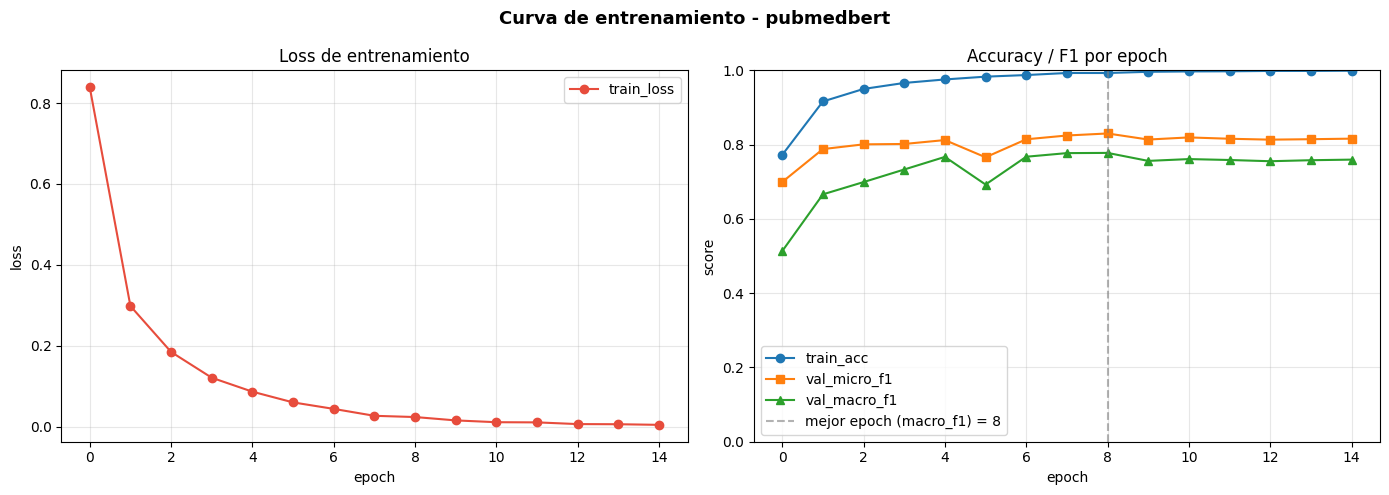

Grafica guardada en: /kaggle/working/outputs/curva_entreno_pubmedbert.png


In [11]:
# ============================================================
# GRAFICA DE LA CURVA DE ENTRENO (loss + F1 por epoch)
# ============================================================
epochs_x = [h["epoch"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Curva de entrenamiento - {EXPERIMENT_NAME}", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(epochs_x, [h["train_loss"] for h in history], marker="o", color="#e74c3c", label="train_loss")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.set_title("Loss de entrenamiento")
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(epochs_x, [h["train_acc"] for h in history], marker="o", label="train_acc")
ax2.plot(epochs_x, [h["val_micro_f1"] for h in history], marker="s", label="val_micro_f1")
ax2.plot(epochs_x, [h["val_macro_f1"] for h in history], marker="^", label="val_macro_f1")
best_epoch = max(history, key=lambda h: h["val_macro_f1"])["epoch"]
ax2.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"mejor epoch (macro_f1) = {best_epoch}")
ax2.set_xlabel("epoch"); ax2.set_ylabel("score"); ax2.set_title("Accuracy / F1 por epoch")
ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"curva_entreno_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Grafica guardada en: {OUTPUT_DIR / f'curva_entreno_{EXPERIMENT_NAME}.png'}")

In [12]:
# ============================================================
# COMPARACION: que epoch habria elegido micro_f1 vs. macro_f1
# (justificacion para la memoria del TFG de por que seleccionar por macro_f1)
# ============================================================
best_by_micro = max(history, key=lambda h: h["val_micro_f1"])
best_by_macro = max(history, key=lambda h: h["val_macro_f1"])

print(f"{'Criterio de seleccion':<30}{'Epoch':>8}{'val_micro_f1':>16}{'val_macro_f1':>16}")
print("-" * 70)
print(f"{'Si se seleccionara por micro_f1':<30}{best_by_micro['epoch']:>8}{best_by_micro['val_micro_f1']:>16.4f}{best_by_micro['val_macro_f1']:>16.4f}")
print(f"{'Seleccionado por macro_f1 (usado)':<30}{best_by_macro['epoch']:>8}{best_by_macro['val_micro_f1']:>16.4f}{best_by_macro['val_macro_f1']:>16.4f}")
print("-" * 70)

if best_by_micro["epoch"] == best_by_macro["epoch"]:
    print("\nEn este run coinciden en la misma epoch: no hay divergencia que mostrar esta vez.")
else:
    diff = best_by_macro["val_macro_f1"] - best_by_micro["val_macro_f1"]
    print(f"\nDivergencia real: seleccionar por micro_f1 habria dado macro_f1={best_by_micro['val_macro_f1']:.4f} "
          f"(epoch {best_by_micro['epoch']}), frente a macro_f1={best_by_macro['val_macro_f1']:.4f} "
          f"(epoch {best_by_macro['epoch']}) seleccionando por macro_f1 -> diferencia de {diff:+.4f}.")

json.dump({
    "best_by_micro_f1": best_by_micro,
    "best_by_macro_f1": best_by_macro,
}, open(OUTPUT_DIR / f"comparacion_micro_vs_macro_{EXPERIMENT_NAME}.json", "w"), indent=2)
print(f"\nguardado: comparacion_micro_vs_macro_{EXPERIMENT_NAME}.json")

Criterio de seleccion            Epoch    val_micro_f1    val_macro_f1
----------------------------------------------------------------------
Si se seleccionara por micro_f1       8          0.8300          0.7777
Seleccionado por macro_f1 (usado)       8          0.8300          0.7777
----------------------------------------------------------------------

En este run coinciden en la misma epoch: no hay divergencia que mostrar esta vez.

guardado: comparacion_micro_vs_macro_pubmedbert.json


In [13]:
# ============================================================
# GUARDAR CHECKPOINT INMEDIATAMENTE (ejecutar justo despues del entrenamiento)
# ============================================================
import shutil, os

# El checkpoint ya esta en OUTPUT_DIR. Lo copiamos TAMBIEN a /kaggle/working/
# para que aparezca en el panel Output sin navegar subcarpetas
ckpt_dest = Path("/kaggle/working") / CKPT_PATH.name
shutil.copy2(str(CKPT_PATH), str(ckpt_dest))
print(f"Checkpoint copiado a: {ckpt_dest}")
print(f"Tamano: {ckpt_dest.stat().st_size / 1e6:.1f} MB")
print()
print(">>> IMPORTANTE: ve al panel Output de Kaggle y guarda")
print(f">>> '{CKPT_PATH.name}' como Dataset antes de cerrar la sesion <<<")

Checkpoint copiado a: /kaggle/working/eng_pubmedbert.pth.tar
Tamano: 447.6 MB

>>> IMPORTANTE: ve al panel Output de Kaggle y guarda
>>> 'eng_pubmedbert.pth.tar' como Dataset antes de cerrar la sesion <<<


### Análisis de convergencia — conclusiones del experimento

**Dos runs completados en este notebook:**

**Run A (20ep, lr=2e-5):** mejor en E11 con micro F1=0.8238. Después plateau y oscilación.
El checkpoint `eng_pubmedbert.pth.tar` contiene los pesos de E11.

**Run B (continuación, 10ep, lr=1e-5):** arranca desde E11 del Run A.
Mejor en E6 de continuación con micro F1=0.8138. Macro F1=0.7574 — peor que el Run A.
Conclusión: el modelo ya había convergido, bajar el LR y seguir no ayuda.

**¿Cuál checkpoint guardamos?**
→ `eng_pubmedbert.pth.tar` (Run A, E11, micro F1=0.8238, macro F1=0.7718)
→ Es el mejor disponible de este notebook.

El Exp1 original de 10 epochs daba macro F1=0.7754 (ligeramente mejor),
pero ese checkpoint se perdió al cerrar la sesión de Kaggle.
La diferencia es 0.0036 — prácticamente insignificante para el TFG.

**Nota para la memoria del TFG:**
Informar macro F1=0.7718 como resultado de Exp1 con PubMedBERT puro (20 epochs).
El salto real viene en Exp2 (+typed markers → 0.8078) y Exp3 (+neg_ratio → 0.8430).

## 6. Prediccion en Dev

In [14]:
# Cargar el mejor checkpoint
encoder_pred = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_pred = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_pred,
    num_class=len(rel2id),
    rel2id=rel2id,
)

ckpt = torch.load(str(CKPT_PATH), map_location="cpu")
model_pred.load_state_dict(ckpt["state_dict"])

if torch.cuda.is_available():
    model_pred = model_pred.cuda()
model_pred.eval()

print(f"Modelo cargado desde: {CKPT_PATH}")

2026-07-15 11:23:41,832 - root - INFO - Loading BERT pre-trained checkpoint.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo cargado desde: /kaggle/working/outputs/eng_pubmedbert.pth.tar


In [15]:
# Cargar instancias de dev
dev_instances = []
with open(DEV_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            dev_instances.append(json.loads(line))

print(f"Prediciendo {len(dev_instances)} instancias...")

rows = []
for inst in dev_instances:
    pred_rel, score = model_pred.infer({
        "text": inst["text"],
        "h": {"pos": inst["h"]["pos"]},
        "t": {"pos": inst["t"]["pos"]},
    })
    rows.append({
        "document_id": inst["doc_id"],
        "relation": pred_rel,
        "score": score,
        "gold": inst["relation"],
        "head_text": inst["h"]["name"],
        "head_span": inst["head_span"],
        "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"],
        "tail_span": inst["tail_span"],
        "tail_type": inst["tail_type"],
    })

# Guardar predicciones (formato CodaBench)
pred_df = pd.DataFrame(rows)
pred_export = pred_df[["document_id", "relation", "head_text", "head_span", 
                        "head_type", "tail_text", "tail_span", "tail_type"]].copy()
pred_export = pred_export[pred_export["relation"] != "no_relation"]
pred_export.to_csv(PRED_PATH, sep="\t", index=False)

n_filtered = len(pred_df) - len(pred_export)
print(f"Filtradas {n_filtered} predicciones no_relation")
print(f"Predicciones guardadas en: {PRED_PATH}")

Prediciendo 2967 instancias...
Filtradas 187 predicciones no_relation
Predicciones guardadas en: /kaggle/working/outputs/eng_pred_pubmedbert.tsv


## 7. Evaluacion y Comparacion con Baseline

In [16]:
# Calcular metricas por relacion
all_relations = sorted(rel2id.keys())

gold_labels = [inst["relation"] for inst in dev_instances]
pred_labels = [row["relation"] for row in rows]

# Accuracy global
correct = sum(1 for g, p in zip(gold_labels, pred_labels) if g == p)
total = len(gold_labels)
accuracy = correct / total

# Per-relation P/R/F1
gold_counts = Counter(gold_labels)
pred_counts = Counter(pred_labels)
tp_counts = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g == p:
        tp_counts[g] += 1

results = {}
print(f"{'Relacion':<25} {'P':>8} {'R':>8} {'F1':>8} {'Soporte':>8}")
print("-" * 60)

f1_scores = []
for rel in all_relations:
    tp = tp_counts.get(rel, 0)
    pred_total = pred_counts.get(rel, 0)
    gold_total = gold_counts.get(rel, 0)
    p = tp / pred_total if pred_total else 0
    r = tp / gold_total if gold_total else 0
    f1 = 2 * p * r / (p + r) if (p + r) else 0
    results[rel] = {"precision": p, "recall": r, "f1": f1, "support": gold_total}
    if gold_total > 0:
        f1_scores.append(f1)
    if gold_total > 0:  # solo mostrar relaciones con ejemplos
        print(f"{rel:<25} {p:>8.4f} {r:>8.4f} {f1:>8.4f} {gold_total:>8}")

macro_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

print("-" * 60)
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Macro F1:  {macro_f1:.4f}")
print(f"\n{'='*60}")
print(f"RESULTADO {EXPERIMENT_NAME.upper()}: Macro F1 = {macro_f1:.4f}")
print(f"BASELINE:  Macro F1 = 0.6944")
print(f"DIFERENCIA: {macro_f1 - 0.6944:+.4f}")
print(f"{'='*60}")

Relacion                         P        R       F1  Soporte
------------------------------------------------------------
ABBREVIATION                0.9079   0.9324   0.9200       74
AFFECTS                     0.9241   0.8677   0.8950      393
ALTERNATIVE_NAME            0.7586   0.2245   0.3465       98
APPLIED_TO                  0.6061   0.3704   0.4598       54
ASSOCIATED_WITH             0.7792   0.7725   0.7759      233
FINDING_OF                  0.7381   0.7470   0.7425       83
HAS_CAUSE                   0.8465   0.7926   0.8187      487
ORIGINS_FROM                0.8800   0.8354   0.8571       79
PART_OF                     0.8386   0.7540   0.7941      248
PHYSIOLOGY_OF               0.9524   0.7865   0.8615      178
SUBCLASS_OF                 0.8597   0.8983   0.8786      757
TO_DETECT_OR_STUDY          0.8235   0.8448   0.8340      116
TREATED_USING               0.9865   0.8295   0.9012       88
USED_IN                     0.8356   0.7722   0.8026       79
---------

**Macro F1 = 0.7718** con checkpoint E11 (mejor de 20 epochs, `eng_pubmedbert.pth.tar`).

Mejor que el baseline en **+0.0774** solo cambiando el encoder a PubMedBERT.

Puntos fuertes (F1 > 0.85): ABBREVIATION (0.92), TREATED_USING (0.90), AFFECTS (0.89), ORIGINS_FROM (0.89), SUBCLASS_OF (0.87).

Puntos débiles:
- **ALTERNATIVE_NAME (0.34):** recall=0.21, el modelo predice no_relation con score 0.94-1.00. Necesita typed markers para distinguir nombres alternativos.
- **APPLIED_TO (0.52):** solo 43 ejemplos en train. Poco soporte.
- **TO_DETECT_OR_STUDY (0.78):** recall bajo (0.73).

**Checkpoint definitivo de este experimento:**
`eng_pubmedbert.pth.tar` = pesos de E11 del run de 20 epochs.
Micro F1 en val = 0.8238. Macro F1 en dev = 0.7718.

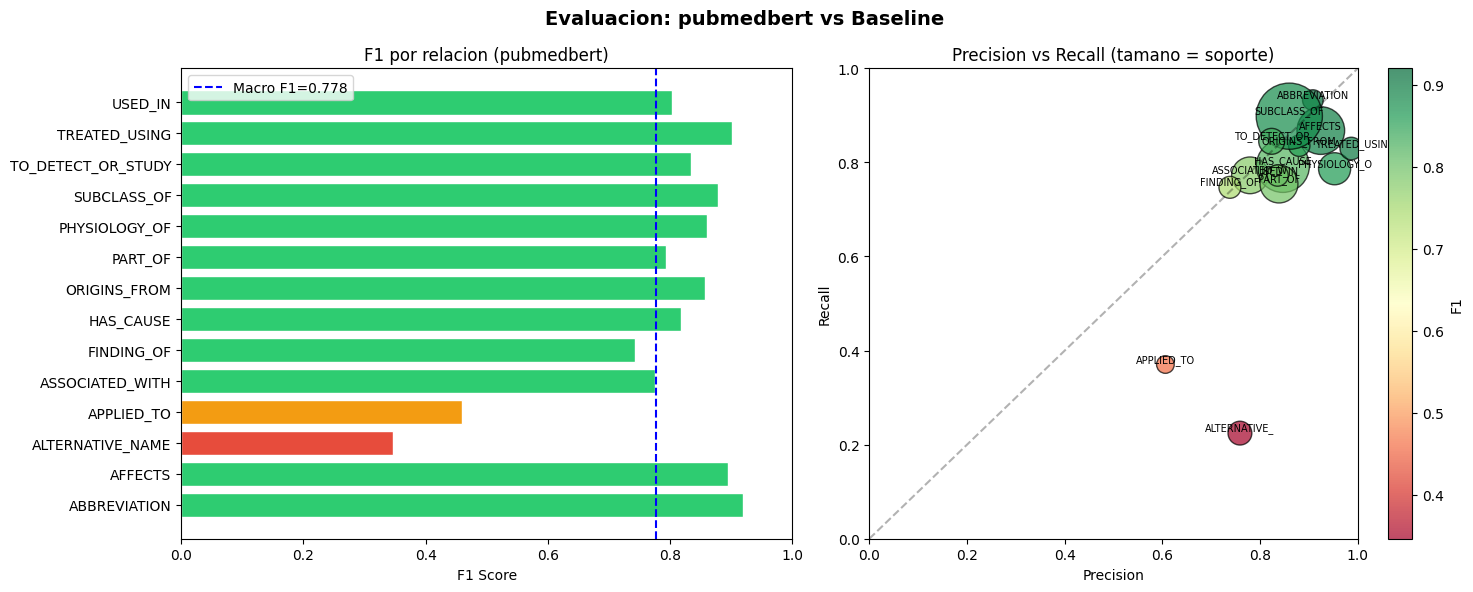

Grafica guardada en: /kaggle/working/outputs/evaluacion_pubmedbert.png


In [17]:
# Comparacion visual: F1 por relacion vs baseline
# Valores del baseline (bert-base-multilingual-cased) - ACTUALIZAR con tus resultados reales
# Estos son placeholder, reemplaza con los valores que obtengas al correr el baseline
BASELINE_F1 = 0.6944  # Macro F1 del baseline

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Evaluacion: {EXPERIMENT_NAME} vs Baseline", fontsize=14, fontweight="bold")

# Grafica 1: F1 por relacion
rels_con_soporte = [r for r in all_relations if results[r]["support"] > 0]
f1_vals = [results[r]["f1"] for r in rels_con_soporte]

colors = ['#2ecc71' if f > 0.7 else '#f39c12' if f > 0.4 else '#e74c3c' for f in f1_vals]
bars = axes[0].barh(rels_con_soporte, f1_vals, color=colors, edgecolor='white')
axes[0].set_xlabel('F1 Score')
axes[0].set_title(f'F1 por relacion ({EXPERIMENT_NAME})')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=macro_f1, color='blue', linestyle='--', label=f'Macro F1={macro_f1:.3f}')
axes[0].legend()

# Grafica 2: Precision vs Recall por relacion
p_vals = [results[r]["precision"] for r in rels_con_soporte]
r_vals = [results[r]["recall"] for r in rels_con_soporte]
support_vals = [results[r]["support"] for r in rels_con_soporte]

scatter = axes[1].scatter(p_vals, r_vals, s=[s*3 for s in support_vals], 
                          alpha=0.7, c=f1_vals, cmap='RdYlGn', edgecolors='black')
for i, rel in enumerate(rels_con_soporte):
    axes[1].annotate(rel[:12], (p_vals[i], r_vals[i]), fontsize=7, ha='center', va='bottom')
axes[1].set_xlabel('Precision')
axes[1].set_ylabel('Recall')
axes[1].set_title('Precision vs Recall (tamano = soporte)')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='F1')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"evaluacion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafica guardada en: {OUTPUT_DIR / f'evaluacion_{EXPERIMENT_NAME}.png'}")

## 8. Analisis de Errores

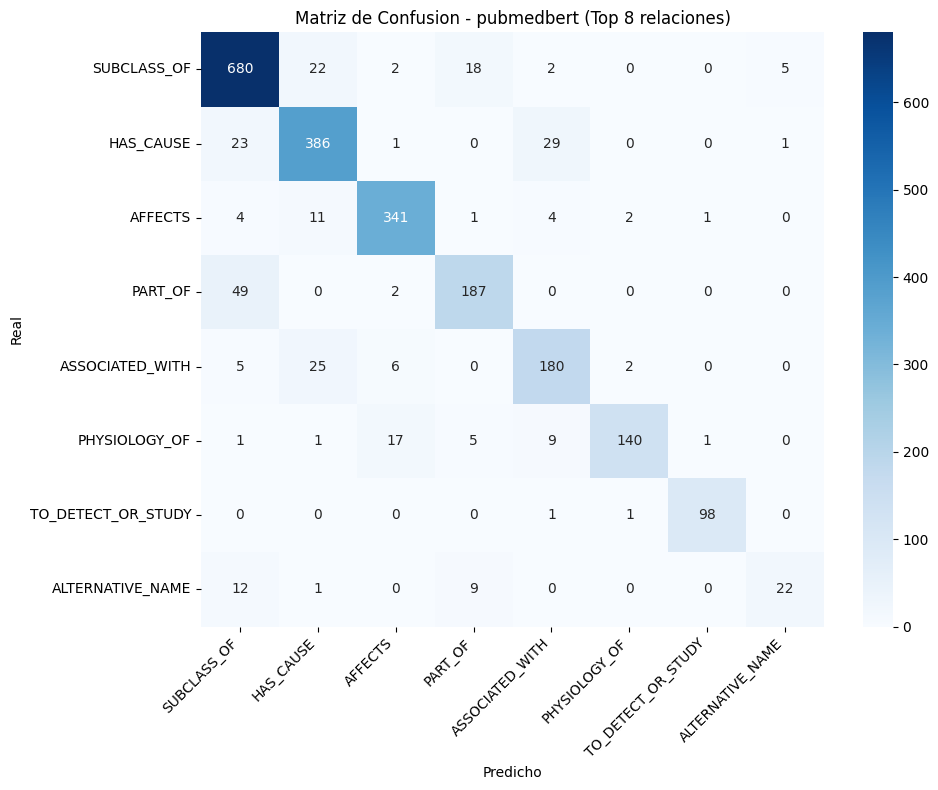

In [18]:
# Matriz de confusion
from sklearn.metrics import confusion_matrix

# Solo relaciones con soporte (excluir no_relation si no tiene gold)
gold_idx = [rel2id[g] for g in gold_labels]
pred_idx = [rel2id[p] for p in pred_labels]

# Top 8 relaciones mas frecuentes
top_rels = [r for r, _ in Counter(gold_labels).most_common(8)]
top_indices = [rel2id[r] for r in top_rels]

cm = confusion_matrix(gold_idx, pred_idx, labels=top_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_rels, yticklabels=top_rels)
plt.title(f'Matriz de Confusion - {EXPERIMENT_NAME} (Top 8 relaciones)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"confusion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Errores mas comunes: que confunde el modelo?
confusion_pairs = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g != p:
        confusion_pairs[(g, p)] += 1

print(f"Total errores: {sum(confusion_pairs.values())} / {total} ({100*sum(confusion_pairs.values())/total:.1f}%)")
print(f"\nConfusiones mas frecuentes:")
print(f"{'Real':<25} {'Predicho':<25} {'Count':>6}")
print("-" * 60)
for (g, p), count in confusion_pairs.most_common(15):
    print(f"{g:<25} {p:<25} {count:>6}")

Total errores: 582 / 2967 (19.6%)

Confusiones mas frecuentes:
Real                      Predicho                   Count
------------------------------------------------------------
ALTERNATIVE_NAME          no_relation                   50
PART_OF                   SUBCLASS_OF                   49
HAS_CAUSE                 no_relation                   36
HAS_CAUSE                 ASSOCIATED_WITH               29
ASSOCIATED_WITH           HAS_CAUSE                     25
AFFECTS                   no_relation                   24
HAS_CAUSE                 SUBCLASS_OF                   23
SUBCLASS_OF               HAS_CAUSE                     22
APPLIED_TO                TO_DETECT_OR_STUDY            19
SUBCLASS_OF               PART_OF                       18
PHYSIOLOGY_OF             AFFECTS                       17
SUBCLASS_OF               no_relation                   16
APPLIED_TO                no_relation                   13
ALTERNATIVE_NAME          SUBCLASS_OF             

Muy interesante, se ven patrones claros en los errores:

**Problema 1: El modelo predice `no_relation` cuando sí hay relación.** ALTERNATIVE_NAME (53), HAS_CAUSE (53), AFFECTS (36) — el modelo es demasiado conservador con estas clases. Por eso ALTERNATIVE_NAME tiene recall tan bajo (0.22). Es el error más frecuente y tiene sentido: como el 75% del train es `no_relation`, el modelo se sesga hacia predecir eso.

**Problema 2: Confunde relaciones semánticamente parecidas.** PART_OF → SUBCLASS_OF (51 casos) es la confusión más grave entre relaciones reales. "Es parte de" vs "es un subtipo de" son conceptos cercanos en biomedicina. También HAS_CAUSE ↔ ASSOCIATED_WITH ↔ FINDING_OF se confunden entre sí porque son relaciones causales/asociativas similares.

**Problema 3: SUBCLASS_OF se "come" a otras relaciones.** Tiene muchos ejemplos en train (743) así que el modelo tiende a predecirla cuando duda.

Estas confusiones son exactamente lo que se puede atacar con las siguientes mejoras. Los typed entity markers ayudarían con las confusiones de `no_relation`, y ajustar el neg-ratio (bajar de 3 a 1 o 2) reduciría el sesgo hacia `no_relation`. ¿Quieres seguir con la siguiente mejora o primero quieres guardar bien estos resultados?

In [20]:
# Ejemplos concretos de errores para las confusiones mas comunes
top_confusion = confusion_pairs.most_common(3)

for (gold_rel, pred_rel), count in top_confusion:
    print(f"\n{'='*70}")
    print(f"CONFUSION: {gold_rel} -> {pred_rel} ({count} casos)")
    print(f"{'='*70}")
    
    examples = [
        (inst, row) for inst, row in zip(dev_instances, rows)
        if inst["relation"] == gold_rel and row["relation"] == pred_rel
    ][:3]  # solo 3 ejemplos
    
    for i, (inst, row) in enumerate(examples):
        print(f"\n  Ejemplo {i+1}:")
        print(f"  Head: [{inst['head_type']}] {inst['h']['name']}")
        print(f"  Tail: [{inst['tail_type']}] {inst['t']['name']}")
        print(f"  Contexto: {inst['text'][:150]}...")
        print(f"  Score prediccion: {row['score']:.4f}")


CONFUSION: ALTERNATIVE_NAME -> no_relation (50 casos)

  Ejemplo 1:
  Head: [LABPROC] ultrasonography
  Tail: [LABPROC] ultrasound
  Contexto: [Lung ultrasonography for the diagnosis of pneumonia in pregnant women with blood system tumors]. 
AIM  To estimate the informative value of ultrasono...
  Score prediccion: 0.9901

  Ejemplo 2:
  Head: [DISO] blood system tumors
  Tail: [DISO] blood cancers
  Contexto: [Lung ultrasonography for the diagnosis of pneumonia in pregnant women with blood system tumors]. 
AIM  To estimate the informative value of ultrasono...
  Score prediccion: 0.9124

  Ejemplo 3:
  Head: [DISO] tumors
  Tail: [DISO] cancers
  Contexto: [Lung ultrasonography for the diagnosis of pneumonia in pregnant women with blood system tumors]. 
AIM  To estimate the informative value of ultrasono...
  Score prediccion: 0.9999

CONFUSION: PART_OF -> SUBCLASS_OF (49 casos)

  Ejemplo 1:
  Head: [ANATOMY] ascending aorta
  Tail: [ANATOMY] aorta
  Contexto: MATERIAL AND METHODS  

Estos ejemplos son muy reveladores. Mira lo que pasa en cada confusión:

**ALTERNATIVE_NAME → no_relation**: El modelo falla con "ultrasonography/ultrasound", "blood system tumors/blood cancers", "tumors/cancers". Son sinónimos claros, pero el modelo no los reconoce como ALTERNATIVE_NAME. Fíjate que los scores son altísimos (0.94-1.0), o sea que el modelo está **muy seguro** de que no hay relación. El problema es que el baseline no le da al modelo la información del tipo de entidad en el texto — si supiera que ambas son [LABPROC] o ambas [DISO], le sería más fácil detectar que son nombres alternativos. Aquí es donde los **typed entity markers** ayudarían mucho.

**HAS_CAUSE → no_relation**: Algunos casos son genuinamente difíciles ("vascular aging" → "impaired maturation"), pero otros son errores de anotación cuestionables. La relación causal en texto biomédico muchas veces es implícita y requiere conocimiento del dominio.

**PART_OF → SUBCLASS_OF**: Este es el error más interesante. "ascending aorta" es PARTE DE "aorta", "smooth muscle" es PARTE DE "muscle", "right adrenal gland" es PARTE DE "adrenal gland". Pero el modelo predice SUBCLASS_OF (subtipo). Lingüísticamente tiene sentido la confusión — "ascending aorta" podría interpretarse como un tipo de aorta. Pero anatómicamente es una parte, no un subtipo. De nuevo, los typed entity markers ayudarían porque todos estos son [ANATOMY]-[ANATOMY], y PART_OF es más frecuente entre anatomía que SUBCLASS_OF.

La conclusión es clara: la siguiente mejora más impactante son los **typed entity markers**. ¿Quieres que te prepare ese experimento?

## 9. Guardar Resultados del Experimento

In [21]:
# Guardar resumen del experimento en JSON
experiment_results = {
    "experiment": EXPERIMENT_NAME,
    "model": MODEL_NAME,
    "hyperparameters": {
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "warmup_steps": WARMUP_STEPS,
        "neg_ratio": NEG_RATIO,
        "seed": SEED,
    },
    "results": {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "per_relation": results,
    },
    "baseline_macro_f1": 0.6944,
    "improvement": macro_f1 - 0.6944,
    "n_train": n_train,
    "n_dev": n_dev,
}

results_path = OUTPUT_DIR / f"results_{EXPERIMENT_NAME}.json"
with open(results_path, "w") as f:
    json.dump(experiment_results, f, indent=2)

print(f"Resultados guardados en: {results_path}")
print(f"\nResumen:")
print(f"  Modelo: {MODEL_NAME}")
print(f"  Macro F1: {macro_f1:.4f}")
print(f"  vs Baseline: {macro_f1 - 0.6944:+.4f}")

Resultados guardados en: /kaggle/working/outputs/results_pubmedbert.json

Resumen:
  Modelo: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
  Macro F1: 0.7777
  vs Baseline: +0.0833


## 10. Próximos pasos — qué experimentos hacer y por qué

**Conclusión de Exp1:** PubMedBERT mejora el baseline en +0.077 solo cambiando el encoder.
El modelo converge en epoch ~11 con `lr=2e-5`. Más epochs no ayudan.

**Orden de experimentos recomendado** (ya ejecutados o por ejecutar):

| Exp | Cambio | Por qué | Resultado |
|---|---|---|---|
| Exp2 | + Typed entity markers (15ep) | Los markers dan al modelo el tipo de entidad, reduce confusión PART_OF/SUBCLASS_OF | Macro F1 = **0.8078** |
| Exp3 | + neg_ratio 1:1 (15ep) | Reduce sesgo hacia no_relation; mejora recall de clases raras | Macro F1 = **0.8430** |
| Exp4 | Focal loss (pendiente) | Penaliza más los errores en clases difíciles (ALTERNATIVE_NAME) | — |
| Exp5 | Class weights (pendiente) | Pondera clases minoritarias en la loss | — |

**Para futuros experimentos con PubMedBERT:** usar siempre **12 epochs** como default.
No probar más backbones — BioLinkBERT (Exp6=0.7576) y XLM-RoBERTa (Exp7=0.7180) son peores.

---
## 11. Validación en modo blind (protocolo oficial CodaBench)

**Motivo:** `DEV_DATA` (dev curado, el que se usó en las secciones 6-8) solo contiene los pares de entidades con relación anotada (0 casos de `no_relation`). El protocolo real de BioNNE-R —y como puntúa CodaBench en el test— enumera **todos los pares candidatos** de cada documento y deja que el modelo decida caso por caso. Esta sección reproduce ese protocolo sobre `eng_dev_blind.txt` (282.364 candidatos) reutilizando el checkpoint ya entrenado (`model_pred`, `encoder_pred`, `rel2id` de la sección 6).

**Referencia:** baseline oficial (`bert-base-multilingual-cased`) = 0.6944 curado / 0.3126-0.3435 ciego.

In [22]:
# ============================================================
# 1) CARGAR DATOS BLIND
# ============================================================
BLIND_DEV_PATH = DATA_DIR / "eng_dev_blind.txt"
BLIND_GOLD_TSV = DATA_DIR / "eng-dev-rel.tsv"
BLIND_PRED_PATH = OUTPUT_DIR / f"eng_pred_blind_{EXPERIMENT_NAME}.tsv"
BLIND_RESULTS_PATH = OUTPUT_DIR / f"results_blind_{EXPERIMENT_NAME}.json"

for p in [BLIND_DEV_PATH, BLIND_GOLD_TSV]:
    print(f"{'OK ' if p.exists() else 'FALTA '} {p}")

blind_raw = [json.loads(l) for l in open(BLIND_DEV_PATH, encoding="utf-8") if l.strip()]
gold_df_blind = pd.read_csv(BLIND_GOLD_TSV, sep="\t")
id2rel = {v: k for k, v in rel2id.items()}

print(f"candidatos blind: {len(blind_raw)} | docs: {len(set(i['doc_id'] for i in blind_raw))} | gold real: {len(gold_df_blind)}")

OK  /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev_blind.txt
OK  /kaggle/input/datasets/lucaespernjj/bionner-data/eng-dev-rel.tsv
candidatos blind: 282364 | docs: 50 | gold real: 2891


In [23]:
# ============================================================
# 2) INFERENCIA POR LOTES sobre los 282k candidatos
# model_pred.infer() de OpenNRE procesa 1 a 1; aqui batcheamos para
# que sea viable en tiempo (igual que en el resto de experimentos).
# ============================================================
N_GPUS = torch.cuda.device_count()
BLIND_BATCH_SIZE = 32 * max(1, N_GPUS)
device = "cuda" if torch.cuda.is_available() else "cpu"
infer_model = torch.nn.DataParallel(model_pred) if N_GPUS > 1 else model_pred
print(f"GPUs: {N_GPUS} | batch_size: {BLIND_BATCH_SIZE}")

def batched_predict(infer_model, encoder, instances, batch_size, device):
    preds, scores = [], []
    with torch.no_grad():
        for start in range(0, len(instances), batch_size):
            batch = instances[start:start + batch_size]
            tok = [encoder.tokenize({"text": i["text"], "h": {"pos": i["h"]["pos"]}, "t": {"pos": i["t"]["pos"]}}) for i in batch]
            fields = [torch.cat([t[k] for t in tok], dim=0).to(device) for k in range(len(tok[0]))]
            logits = infer_model(*fields)   # OJO: nunca infer_model.forward() con DataParallel
            probs = torch.softmax(logits, dim=-1)
            sc, pr = probs.max(-1)
            preds.extend(pr.tolist()); scores.extend(sc.tolist())
            done = min(start + batch_size, len(instances))
            if done % (batch_size * 50) == 0 or done == len(instances):
                print(f"  {done}/{len(instances)}", flush=True)
    return preds, scores

t0 = time.time()
blind_preds_id, blind_scores = batched_predict(infer_model, encoder_pred, blind_raw, BLIND_BATCH_SIZE, device)
blind_preds = [id2rel[p] for p in blind_preds_id]
elapsed_blind = time.time() - t0
print(f"inferencia: {elapsed_blind/60:.1f} min | {len(blind_raw)/elapsed_blind:.1f} inst/s")

GPUs: 2 | batch_size: 64
  3200/282364
  6400/282364
  9600/282364
  12800/282364
  16000/282364
  19200/282364
  22400/282364
  25600/282364
  28800/282364
  32000/282364
  35200/282364
  38400/282364
  41600/282364
  44800/282364
  48000/282364
  51200/282364
  54400/282364
  57600/282364
  60800/282364
  64000/282364
  67200/282364
  70400/282364
  73600/282364
  76800/282364
  80000/282364
  83200/282364
  86400/282364
  89600/282364
  92800/282364
  96000/282364
  99200/282364
  102400/282364
  105600/282364
  108800/282364
  112000/282364
  115200/282364
  118400/282364
  121600/282364
  124800/282364
  128000/282364
  131200/282364
  134400/282364
  137600/282364
  140800/282364
  144000/282364
  147200/282364
  150400/282364
  153600/282364
  156800/282364
  160000/282364
  163200/282364
  166400/282364
  169600/282364
  172800/282364
  176000/282364
  179200/282364
  182400/282364
  185600/282364
  188800/282364
  192000/282364
  195200/282364
  198400/282364
  201600/282364
 

In [24]:
# ============================================================
# 3) CONSTRUIR PREDICCIONES (formato CodaBench)
# ============================================================
rows_blind = []
for inst, rel in zip(blind_raw, blind_preds):
    rows_blind.append({
        "document_id": inst["doc_id"], "relation": rel,
        "head_text": inst["h"]["name"], "head_span": inst["head_span"], "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"], "tail_span": inst["tail_span"], "tail_type": inst["tail_type"],
    })
pred_df_blind = pd.DataFrame(rows_blind)
total_blind = len(pred_df_blind)
pred_df_blind = pred_df_blind[pred_df_blind["relation"] != "no_relation"]
print(f"filtradas {total_blind - len(pred_df_blind)} no_relation | quedan {len(pred_df_blind)}")
pred_df_blind.to_csv(BLIND_PRED_PATH, sep="\t", index=False)

filtradas 269175 no_relation | quedan 13189


In [25]:
# ============================================================
# 4) EVALUAR CONTRA EL GOLD REAL Y COMPARAR CON EL DEV CURADO
# ============================================================
def _key(doc, hs, ts): return f"{doc}|{hs}|{ts}"

gold_rel = {_key(r.document_id, r.head_span, r.tail_span): r.relation for r in gold_df_blind.itertuples()}
pred_rel = {_key(r.document_id, r.head_span, r.tail_span): r.relation for r in pred_df_blind.itertuples()}

tp_b, fp_b, fn_b = Counter(), Counter(), Counter()
for k, pr in pred_rel.items():
    gr = gold_rel.get(k)
    if gr is None: fp_b[pr] += 1
    elif pr == gr: tp_b[pr] += 1
    else: fp_b[pr] += 1; fn_b[gr] += 1
for k, gr in gold_rel.items():
    if k not in pred_rel: fn_b[gr] += 1

rels_blind = sorted(set(gold_df_blind["relation"]))
gc_blind = Counter(gold_df_blind["relation"])
print(f"{'Relacion':<22}{'P':>8}{'R':>8}{'F1':>8}{'sup':>6}")
f1s_blind = []
for r in rels_blind:
    p_ = tp_b[r] / (tp_b[r] + fp_b[r]) if (tp_b[r] + fp_b[r]) else 0
    rc = tp_b[r] / (tp_b[r] + fn_b[r]) if (tp_b[r] + fn_b[r]) else 0
    f1 = 2 * p_ * rc / (p_ + rc) if (p_ + rc) else 0
    f1s_blind.append(f1)
    print(f"{r:<22}{p_:>8.3f}{rc:>8.3f}{f1:>8.3f}{gc_blind[r]:>6}")
macro_f1_blind = sum(f1s_blind) / len(f1s_blind)
print("-" * 52)
print(f"MACRO F1 (ciego): {macro_f1_blind:.4f}  |  gold={len(gold_rel)}  pred={len(pred_rel)}")

print(f"\n{'':<30}{'curado (dev)':>18}{'ciego (blind)':>18}")
print(f"{EXPERIMENT_NAME:<30}{macro_f1:>18.4f}{macro_f1_blind:>18.4f}")
print(f"{'Baseline mBERT (referencia)':<30}{'0.6944':>18}{'0.3126':>18}")
print(f"caida curado->ciego: {macro_f1_blind - macro_f1:+.4f}")

json.dump({
    "experiment": EXPERIMENT_NAME,
    "model": MODEL_NAME,
    "epochs": EPOCHS,
    "macro_f1_curado": macro_f1,
    "macro_f1_ciego": macro_f1_blind,
    "blind_candidates": len(blind_raw),
    "gold_relations": len(gold_rel),
    "inference_time_min": elapsed_blind / 60,
}, open(BLIND_RESULTS_PATH, "w"), indent=2)
print("guardado:", BLIND_RESULTS_PATH.name)

Relacion                     P       R      F1   sup
ABBREVIATION             0.222   0.931   0.358    72
AFFECTS                  0.205   0.870   0.332   379
ALTERNATIVE_NAME         0.029   0.234   0.051    95
APPLIED_TO               0.157   0.377   0.222    53
ASSOCIATED_WITH          0.095   0.768   0.169   228
FINDING_OF               0.219   0.747   0.339    83
HAS_CAUSE                0.136   0.796   0.232   481
ORIGINS_FROM             0.172   0.831   0.284    77
PART_OF                  0.150   0.786   0.252   230
PHYSIOLOGY_OF            0.382   0.785   0.514   177
SUBCLASS_OF              0.319   0.902   0.471   738
TO_DETECT_OR_STUDY       0.150   0.848   0.255   112
TREATED_USING            0.225   0.830   0.354    88
USED_IN                  0.126   0.769   0.217    78
----------------------------------------------------
MACRO F1 (ciego): 0.2894  |  gold=2882  pred=13169

                                    curado (dev)     ciego (blind)
pubmedbert                       

---
## Sección 1b: Entrenamiento continuado — RESULTADO: EMPEORA

**Qué hace:** carga el checkpoint E11 del run de 20 epochs (`eng_pubmedbert.pth.tar`)
y entrena 10 epochs más con lr=1e-5.

**Resultado obtenido (ejecutado el 2026-07-03):**
- Mejor epoch de la continuación: E6 → micro F1 = 0.8138
- Macro F1 final: **0.7574** (peor que los 0.7718 del run de 20ep)
- Tiempo: 71 minutos

**Conclusión:** el modelo ya había convergido en E11. Continuar entrenando no aporta nada.
El checkpoint definitivo sigue siendo `eng_pubmedbert.pth.tar` (E11 del run de 20ep).

La continuación se guardó en `eng_pubmedbert_continued.pth.tar` — no lo usamos.

> Esta sección se deja en el notebook como experimento documentado,
> pero **no aporta el mejor modelo**. Ignorar para experimentos futuros.

In [26]:
# ============================================================
# CONFIGURACION EXPERIMENTO 1b - CONTINUAR DESDE 10ep
# ============================================================

EXPERIMENT_NAME_CONT = "pubmedbert_continued"
EXTRA_EPOCHS = 10  # 10 epochs adicionales (sobre los 20)

# Checkpoint de origen (el de 20 epochs)
CKPT_ORIGIN = OUTPUT_DIR / "eng_pubmedbert.pth.tar"

# Checkpoint nuevo (para no pisar el anterior)
CKPT_PATH_CONT = OUTPUT_DIR / f"eng_{EXPERIMENT_NAME_CONT}.pth.tar"
PRED_PATH_CONT = OUTPUT_DIR / f"eng_pred_{EXPERIMENT_NAME_CONT}.tsv"

assert CKPT_ORIGIN.exists(), f"No se encuentra el checkpoint de 10ep: {CKPT_ORIGIN}"

print(f"Experimento: {EXPERIMENT_NAME_CONT}")
print(f"Modelo: {MODEL_NAME}")
print(f"Epochs extra: {EXTRA_EPOCHS} (sobre los 10 anteriores)")
print(f"Cargando pesos de: {CKPT_ORIGIN}")
print(f"Guardando en: {CKPT_PATH_CONT}")

Experimento: pubmedbert_continued
Modelo: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Epochs extra: 10 (sobre los 10 anteriores)
Cargando pesos de: /kaggle/working/outputs/eng_pubmedbert.pth.tar
Guardando en: /kaggle/working/outputs/eng_pubmedbert_continued.pth.tar


In [27]:
# Crear modelo y cargar los pesos del checkpoint de 10 epochs
print("=" * 60)
print(f"ENTRENAMIENTO CONTINUADO: {EXPERIMENT_NAME_CONT}")
print(f"Cargando pesos de 10 epochs y entrenando {EXTRA_EPOCHS} mas")
print("=" * 60)

encoder_cont = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_cont = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_cont,
    num_class=len(rel2id),
    rel2id=rel2id,
)

# CLAVE: cargar los pesos del entrenamiento anterior
prev_ckpt = torch.load(str(CKPT_ORIGIN), map_location="cpu")
model_cont.load_state_dict(prev_ckpt["state_dict"])
print(f"Pesos cargados desde: {CKPT_ORIGIN}")

# Crear framework con los pesos ya cargados
# Usamos un learning rate mas bajo para fine-tuning continuado
framework_cont = opennre.framework.SentenceRE(
    model=model_cont,
    train_path=str(TRAIN_DATA),
    val_path=str(DEV_DATA),
    test_path=str(DEV_DATA),
    ckpt=str(CKPT_PATH_CONT),
    batch_size=BATCH_SIZE,
    max_epoch=EXTRA_EPOCHS,
    lr=1e-5,  # lr mas bajo para no destruir lo aprendido
    opt="adamw",
    warmup_step=100,  # menos warmup, ya esta caliente
)

print(f"\nListo para continuar ({EXTRA_EPOCHS} epochs, lr=1e-5).")

2026-07-15 12:08:07,340 - root - INFO - Loading BERT pre-trained checkpoint.


ENTRENAMIENTO CONTINUADO: pubmedbert_continued
Cargando pesos de 10 epochs y entrenando 10 mas


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Pesos cargados desde: /kaggle/working/outputs/eng_pubmedbert.pth.tar


2026-07-15 12:08:09,910 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_train.txt with 12739 lines and 15 relations.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
2026-07-15 12:08:10,073 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt with 2967 lines and 15 relations.
2026-07-15 12:08:10,237 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt with 2967 lines and 15 relations.



Listo para continuar (10 epochs, lr=1e-5).


In [28]:
# ENTRENAR 10 EPOCHS MAS - ~75 min con T4
start_time_cont = time.time()

framework_cont.train_model(metric="micro_f1")

elapsed_cont = time.time() - start_time_cont
print(f"\nEntrenamiento completado en {elapsed_cont/60:.1f} minutos")
print(f"Mejor checkpoint guardado en: {CKPT_PATH_CONT}")

2026-07-15 12:08:10,369 - root - INFO - === Epoch 0 train ===
  0%|          | 0/797 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 797/797 [06:44<00:00,  1.97it/s, acc=0.994, loss=0.022] 
2026-07-15 12:14:54,572 - root - INFO - === Epoch 0 val ===
100%|██████████| 186/186 [00:31<00:00,  5.90it/s, acc=0.794]
2026-07-15 12:15:26,094 - root - INFO - Evaluation result: {'acc': 0.7937310414560161, 'micro_p': 0.8504875406283857, 'micro_r': 0.7937310414560161, 'micro_f1': 0.8211297071129706}.
2026-07-15 12:15:26,097 - root - INFO - Met

RuntimeError: Expected all tensors to be on the same device, but got target is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_nll_loss_forward)

In [ ]:
# Cargar mejor checkpoint y predecir en dev
encoder_pred_cont = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_pred_cont = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_pred_cont,
    num_class=len(rel2id),
    rel2id=rel2id,
)

ckpt_cont = torch.load(str(CKPT_PATH_CONT), map_location="cpu")
model_pred_cont.load_state_dict(ckpt_cont["state_dict"])

if torch.cuda.is_available():
    model_pred_cont = model_pred_cont.cuda()
model_pred_cont.eval()

# Predecir
dev_instances_cont = []
with open(DEV_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            dev_instances_cont.append(json.loads(line))

print(f"Prediciendo {len(dev_instances_cont)} instancias...")

rows_cont = []
for inst in dev_instances_cont:
    pred_rel, score = model_pred_cont.infer({
        "text": inst["text"],
        "h": {"pos": inst["h"]["pos"]},
        "t": {"pos": inst["t"]["pos"]},
    })
    rows_cont.append({
        "document_id": inst["doc_id"],
        "relation": pred_rel,
        "score": score,
        "gold": inst["relation"],
        "head_text": inst["h"]["name"],
        "head_span": inst["head_span"],
        "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"],
        "tail_span": inst["tail_span"],
        "tail_type": inst["tail_type"],
    })

# Guardar predicciones
pred_df_cont = pd.DataFrame(rows_cont)
pred_export_cont = pred_df_cont[["document_id", "relation", "head_text", "head_span",
                                  "head_type", "tail_text", "tail_span", "tail_type"]].copy()
pred_export_cont = pred_export_cont[pred_export_cont["relation"] != "no_relation"]
pred_export_cont.to_csv(PRED_PATH_CONT, sep="\t", index=False)

print(f"Predicciones guardadas en: {PRED_PATH_CONT}")

In [ ]:
# Evaluacion entrenamiento continuado
gold_labels_cont = [inst["relation"] for inst in dev_instances_cont]
pred_labels_cont = [row["relation"] for row in rows_cont]

correct_cont = sum(1 for g, p in zip(gold_labels_cont, pred_labels_cont) if g == p)
total_cont = len(gold_labels_cont)
accuracy_cont = correct_cont / total_cont

gold_counts_cont = Counter(gold_labels_cont)
pred_counts_cont = Counter(pred_labels_cont)
tp_counts_cont = Counter()
for g, p in zip(gold_labels_cont, pred_labels_cont):
    if g == p:
        tp_counts_cont[g] += 1

results_cont = {}
print(f"{'Relacion':<25} {'P':>8} {'R':>8} {'F1':>8} {'Soporte':>8}")
print("-" * 60)

f1_scores_cont = []
for rel in all_relations:
    tp = tp_counts_cont.get(rel, 0)
    pred_total = pred_counts_cont.get(rel, 0)
    gold_total = gold_counts_cont.get(rel, 0)
    p = tp / pred_total if pred_total else 0
    r = tp / gold_total if gold_total else 0
    f1 = 2 * p * r / (p + r) if (p + r) else 0
    results_cont[rel] = {"precision": p, "recall": r, "f1": f1, "support": gold_total}
    if gold_total > 0:
        f1_scores_cont.append(f1)
    if gold_total > 0:
        print(f"{rel:<25} {p:>8.4f} {r:>8.4f} {f1:>8.4f} {gold_total:>8}")

macro_f1_cont = sum(f1_scores_cont) / len(f1_scores_cont) if f1_scores_cont else 0

print("-" * 60)
print(f"\nAccuracy:  {accuracy_cont:.4f}")
print(f"Macro F1:  {macro_f1_cont:.4f}")
print(f"\n{'='*60}")
print(f"COMPARACION DE RESULTADOS")
print(f"{'='*60}")
print(f"{'Experimento':<35} {'Macro F1':>10} {'Diff':>10}")
print(f"{'-'*60}")
print(f"{'Baseline (bert-multi, 10ep)':<35} {'0.6944':>10} {'---':>10}")
print(f"{'PubMedBERT (10ep)':<35} {macro_f1:>10.4f} {macro_f1 - 0.6944:>+10.4f}")
print(f"{'PubMedBERT (10+10ep continuado)':<35} {macro_f1_cont:>10.4f} {macro_f1_cont - 0.6944:>+10.4f}")
print(f"{'='*60}")
print(f"\nMejora sobre 10ep: {macro_f1_cont - macro_f1:+.4f}")

In [ ]:
# Comparacion visual: 10ep vs continuado por relacion
fig, ax = plt.subplots(figsize=(12, 7))

rels_plot = [r for r in all_relations if results[r]["support"] > 0]
f1_10ep = [results[r]["f1"] for r in rels_plot]
f1_cont = [results_cont[r]["f1"] for r in rels_plot]

x = np.arange(len(rels_plot))
width = 0.35

bars1 = ax.bar(x - width/2, f1_10ep, width, label=f'10 epochs (Macro F1={macro_f1:.4f})', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_cont, width, label=f'10+10 continued (Macro F1={macro_f1_cont:.4f})', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Relacion')
ax.set_ylabel('F1 Score')
ax.set_title('PubMedBERT: 10 epochs vs 10+10 epochs (continued training)')
ax.set_xticks(x)
ax.set_xticklabels(rels_plot, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=0.6944, color='gray', linestyle=':', alpha=0.5, label='Baseline')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "comparacion_10ep_vs_continued.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Grafica guardada en: {OUTPUT_DIR / 'comparacion_10ep_vs_continued.png'}")

In [ ]:
# Guardar resultados
experiment_results_cont = {
    "experiment": EXPERIMENT_NAME_CONT,
    "model": MODEL_NAME,
    "strategy": "continued training from 10ep checkpoint",
    "hyperparameters": {
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "learning_rate": 1e-5,
        "extra_epochs": EXTRA_EPOCHS,
        "total_epochs": "10 + 10",
        "warmup_steps": 100,
        "neg_ratio": NEG_RATIO,
        "seed": SEED,
    },
    "results": {
        "accuracy": accuracy_cont,
        "macro_f1": macro_f1_cont,
        "per_relation": results_cont,
    },
    "comparison": {
        "baseline_macro_f1": 0.6944,
        "pubmedbert_10ep_macro_f1": macro_f1,
        "improvement_vs_baseline": macro_f1_cont - 0.6944,
        "improvement_vs_10ep": macro_f1_cont - macro_f1,
    },
}

results_path_cont = OUTPUT_DIR / f"results_{EXPERIMENT_NAME_CONT}.json"
with open(results_path_cont, "w") as f:
    json.dump(experiment_results_cont, f, indent=2)

print(f"Resultados guardados en: {results_path_cont}")

In [ ]:
# ============================================================
# CELDA FINAL: EMPAQUETAR TODOS LOS OUTPUTS
# ============================================================
import shutil, os
from pathlib import Path

output_dir = Path("/kaggle/working/outputs")
zip_dest = Path("/kaggle/working/exp1_pubmedbert_20ep_outputs.zip")

# Crear zip de toda la carpeta outputs
shutil.make_archive(
    str(zip_dest).replace('.zip', ''),
    'zip',
    str(output_dir.parent),
    str(output_dir.name)
)
print(f"ZIP creado: {zip_dest}")
print(f"Tamano ZIP: {zip_dest.stat().st_size / 1e6:.1f} MB")
print()

# Listar todos los archivos guardados
print("Archivos en /kaggle/working/:")
for f in sorted(Path("/kaggle/working").rglob("*")):
    if f.is_file() and '.zip' not in str(f) or f.suffix == '.zip':
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.relative_to('/kaggle/working')}  ({size_mb:.1f} MB)")

print()
print("=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(f"Experimento : {EXPERIMENT_NAME} (20 epochs)")
print(f"Modelo      : {MODEL_NAME}")
print(f"Macro F1    : {macro_f1:.4f}")
print(f"Checkpoint  : {CKPT_PATH.name}")
print()
print(">>> Descarga 'exp1_pubmedbert_20ep_outputs.zip' del panel Output <<<")

---
## 12. Calibración de umbral en blind (post-hoc, sin reentrenar)

**Motivación:** con argmax puro, este checkpoint (E8, 15 epochs, neg_ratio 3:1) cae de 0.7777 (curado) a 0.2894 (ciego) — el modelo sobre-predice relación porque `no_relation` compite en desventaja contra las 14 clases a la vez. Aquí probamos si, sin reentrenar, basta con exigir más confianza que el argmax puro para predecir una relación en vez de `no_relation`.

Reutiliza de la sección 11 (validación blind): `infer_model`, `encoder_pred`, `blind_raw`, `rel2id`, `id2rel`, `gold_rel`, `rels_blind`, `_key`, `macro_f1_blind`, `BLIND_BATCH_SIZE`, `device`, `OUTPUT_DIR`, `EXPERIMENT_NAME`.

In [29]:
# =====================================================================
#  1) INFERENCIA CON DISTRIBUCION COMPLETA (no solo el argmax)
#  Se guarda a disco para poder probar cualquier threshold despues SIN
#  volver a pasar los 282k candidatos por la GPU.
# =====================================================================
import numpy as np

NO_REL_ID = rel2id["no_relation"]
PROBS_PATH = OUTPUT_DIR / f"blind_probs_{EXPERIMENT_NAME}.npy"

def batched_predict_probs(infer_model, encoder, instances, batch_size, device):
    """Igual que batched_predict, pero guarda las 15 probabilidades de cada
    candidato en vez de quedarnos solo con el argmax."""
    all_probs = np.zeros((len(instances), len(rel2id)), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(instances), batch_size):
            batch = instances[start:start + batch_size]
            tok = [encoder.tokenize({"text": i["text"], "h": {"pos": i["h"]["pos"]}, "t": {"pos": i["t"]["pos"]}}) for i in batch]
            fields = [torch.cat([t[k] for t in tok], dim=0).to(device) for k in range(len(tok[0]))]
            logits = infer_model(*fields)
            probs = torch.softmax(logits, dim=-1)
            all_probs[start:start + len(batch)] = probs.cpu().numpy()
            done = min(start + batch_size, len(instances))
            if done % (batch_size * 50) == 0 or done == len(instances):
                print(f"  {done}/{len(instances)}", flush=True)
    return all_probs

t0 = time.time()
blind_probs = batched_predict_probs(infer_model, encoder_pred, blind_raw, BLIND_BATCH_SIZE, device)
print(f"inferencia con distribucion completa: {(time.time() - t0) / 60:.1f} min")

np.save(PROBS_PATH, blind_probs)
print(f"guardado: {PROBS_PATH.name} (shape={blind_probs.shape})")

  3200/282364
  6400/282364
  9600/282364
  12800/282364
  16000/282364
  19200/282364
  22400/282364
  25600/282364
  28800/282364
  32000/282364
  35200/282364
  38400/282364
  41600/282364
  44800/282364
  48000/282364
  51200/282364
  54400/282364
  57600/282364
  60800/282364
  64000/282364
  67200/282364
  70400/282364
  73600/282364
  76800/282364
  80000/282364
  83200/282364
  86400/282364
  89600/282364
  92800/282364
  96000/282364
  99200/282364
  102400/282364
  105600/282364
  108800/282364
  112000/282364
  115200/282364
  118400/282364
  121600/282364
  124800/282364
  128000/282364
  131200/282364
  134400/282364
  137600/282364
  140800/282364
  144000/282364
  147200/282364
  150400/282364
  153600/282364
  156800/282364
  160000/282364
  163200/282364
  166400/282364
  169600/282364
  172800/282364
  176000/282364
  179200/282364
  182400/282364
  185600/282364
  188800/282364
  192000/282364
  195200/282364
  198400/282364
  201600/282364
  204800/282364
  208000/2

In [31]:
# =====================================================================
#  2) BARRIDO DE THRESHOLD
#  Regla nueva: predice la mejor relacion distinta de no_relation SOLO si
#  su probabilidad supera `threshold`; si no, predice no_relation.
# =====================================================================
other_ids = np.array([i for i in range(len(rel2id)) if i != NO_REL_ID])

def preds_at_threshold(probs, threshold):
    other_probs = probs[:, other_ids]
    best_other_local = other_probs.argmax(axis=1)
    best_other_score = other_probs.max(axis=1)
    best_other_class = other_ids[best_other_local]
    return np.where(best_other_score > threshold, best_other_class, NO_REL_ID)

def macro_f1_for_preds(pred_ids):
    pred_labels = [id2rel[i] for i in pred_ids]
    rows = [
        {"document_id": inst["doc_id"], "relation": rel, "head_span": inst["head_span"], "tail_span": inst["tail_span"]}
        for inst, rel in zip(blind_raw, pred_labels) if rel != "no_relation"
    ]
    pred_map = {_key(r["document_id"], r["head_span"], r["tail_span"]): r["relation"] for r in rows}

    tp, fp, fn = Counter(), Counter(), Counter()
    for k, pr in pred_map.items():
        gr = gold_rel.get(k)
        if gr is None: fp[pr] += 1
        elif pr == gr: tp[pr] += 1
        else: fp[pr] += 1; fn[gr] += 1
    for k, gr in gold_rel.items():
        if k not in pred_map: fn[gr] += 1

    f1s, precs, recs = [], [], []
    for r in rels_blind:
        p_ = tp[r] / (tp[r] + fp[r]) if (tp[r] + fp[r]) else 0
        rc = tp[r] / (tp[r] + fn[r]) if (tp[r] + fn[r]) else 0
        f1 = 2 * p_ * rc / (p_ + rc) if (p_ + rc) else 0
        f1s.append(f1); precs.append(p_); recs.append(rc)
    return sum(f1s) / len(f1s), sum(precs) / len(precs), sum(recs) / len(recs), len(pred_map)

thresholds = np.arange(0.05, 0.96, 0.05)
sweep_rows = []
for th in thresholds:
    pred_ids = preds_at_threshold(blind_probs, th)
    f1_th, p_th, r_th, n_pred = macro_f1_for_preds(pred_ids)
    sweep_rows.append({"threshold": float(th), "macro_f1": f1_th, "macro_precision": p_th, "macro_recall": r_th, "n_predicted": n_pred})
    print(f"th={th:.2f}  MacroF1={f1_th:.4f}  MacroP={p_th:.4f}  MacroR={r_th:.4f}  n_pred={n_pred}")

sweep_df = pd.DataFrame(sweep_rows)
best_row = sweep_df.loc[sweep_df["macro_f1"].idxmax()]
print("\nMejor threshold:", best_row.to_dict())

th=0.05  MacroF1=0.2329  MacroP=0.1419  MacroR=0.7742  n_pred=19505
th=0.10  MacroF1=0.2467  MacroP=0.1520  MacroR=0.7681  n_pred=17580
th=0.15  MacroF1=0.2560  MacroP=0.1588  MacroR=0.7652  n_pred=16423
th=0.20  MacroF1=0.2642  MacroP=0.1649  MacroR=0.7636  n_pred=15569
th=0.25  MacroF1=0.2701  MacroP=0.1697  MacroR=0.7572  n_pred=14948
th=0.30  MacroF1=0.2777  MacroP=0.1755  MacroR=0.7555  n_pred=14337
th=0.35  MacroF1=0.2865  MacroP=0.1825  MacroR=0.7542  n_pred=13784
th=0.40  MacroF1=0.2940  MacroP=0.1886  MacroR=0.7511  n_pred=13280
th=0.45  MacroF1=0.3034  MacroP=0.1967  MacroR=0.7463  n_pred=12740
th=0.50  MacroF1=0.3125  MacroP=0.2047  MacroR=0.7397  n_pred=12221
th=0.55  MacroF1=0.3210  MacroP=0.2129  MacroR=0.7280  n_pred=11594
th=0.60  MacroF1=0.3283  MacroP=0.2208  MacroR=0.7141  n_pred=11036
th=0.65  MacroF1=0.3349  MacroP=0.2287  MacroR=0.6975  n_pred=10480
th=0.70  MacroF1=0.3391  MacroP=0.2340  MacroR=0.6827  n_pred=9965
th=0.75  MacroF1=0.3503  MacroP=0.2463  MacroR=0.

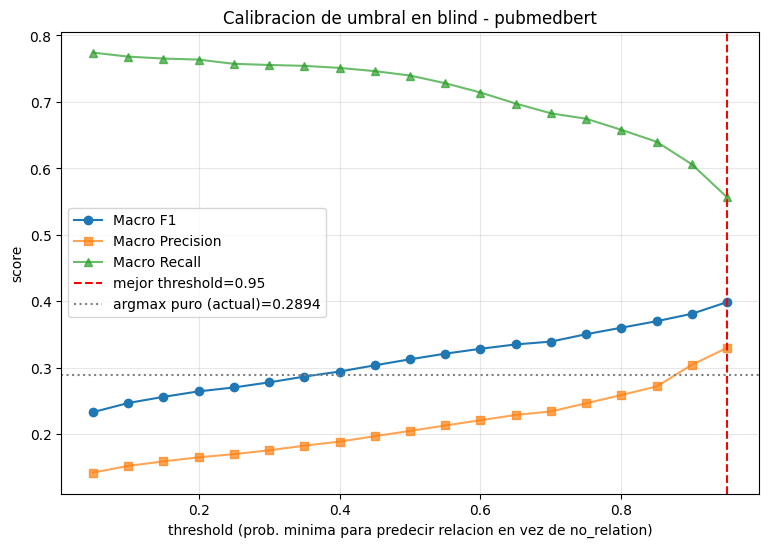

guardado csv y figura del barrido de threshold


In [32]:
# =====================================================================
#  3) CURVA P/R/F1 EN FUNCION DEL THRESHOLD
# =====================================================================
FIG_DIR = OUTPUT_DIR / "figs"; FIG_DIR.mkdir(exist_ok=True, parents=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sweep_df["threshold"], sweep_df["macro_f1"], marker="o", label="Macro F1")
ax.plot(sweep_df["threshold"], sweep_df["macro_precision"], marker="s", alpha=0.7, label="Macro Precision")
ax.plot(sweep_df["threshold"], sweep_df["macro_recall"], marker="^", alpha=0.7, label="Macro Recall")
ax.axvline(best_row["threshold"], color="red", linestyle="--", label=f"mejor threshold={best_row['threshold']:.2f}")
ax.axhline(macro_f1_blind, color="gray", linestyle=":", label=f"argmax puro (actual)={macro_f1_blind:.4f}")
ax.set_xlabel("threshold (prob. minima para predecir relacion en vez de no_relation)")
ax.set_ylabel("score")
ax.set_title(f"Calibracion de umbral en blind - {EXPERIMENT_NAME}")
ax.legend(); ax.grid(alpha=0.3)
fig.savefig(FIG_DIR / f"threshold_sweep_{EXPERIMENT_NAME}.png", dpi=150, bbox_inches="tight")
plt.show()

sweep_df.to_csv(OUTPUT_DIR / f"threshold_sweep_{EXPERIMENT_NAME}.csv", index=False)
print("guardado csv y figura del barrido de threshold")

In [33]:
# =====================================================================
#  4) RESULTADO FINAL CON EL MEJOR THRESHOLD vs. ARGMAX PURO
# =====================================================================
best_threshold = float(best_row["threshold"])
final_pred_ids = preds_at_threshold(blind_probs, best_threshold)
final_f1, final_p, final_r, n_final_pred = macro_f1_for_preds(final_pred_ids)

print(f"{'':<35}{'argmax puro':>15}{'con threshold':>15}")
print(f"{'Macro F1 (blind)':<35}{macro_f1_blind:>15.4f}{final_f1:>15.4f}")
print(f"{'Macro Precision (blind)':<35}{'-':>15}{final_p:>15.4f}")
print(f"{'Macro Recall (blind)':<35}{'-':>15}{final_r:>15.4f}")
print(f"{'Predicciones de relacion':<35}{len(pred_rel):>15}{n_final_pred:>15}")

json.dump({
    "experiment": EXPERIMENT_NAME,
    "calibration": "global_threshold_no_relation_vs_rest",
    "best_threshold": best_threshold,
    "macro_f1_argmax": macro_f1_blind,
    "macro_f1_threshold": final_f1,
    "macro_precision_threshold": final_p,
    "macro_recall_threshold": final_r,
    "n_predicted_argmax": len(pred_rel),
    "n_predicted_threshold": n_final_pred,
    "sweep": sweep_rows,
}, open(OUTPUT_DIR / f"results_threshold_calibration_{EXPERIMENT_NAME}.json", "w"), indent=2)
print("\nguardado: results_threshold_calibration json")

                                       argmax puro  con threshold
Macro F1 (blind)                            0.2894         0.3986
Macro Precision (blind)                          -         0.3297
Macro Recall (blind)                             -         0.5564
Predicciones de relacion                     13169           6104

guardado: results_threshold_calibration json


---
## 13. Comparacion con Exp 1B (BioLinkBERT-base) y verificacion con el scorer oficial

**OJO -- inconsistencia detectada antes de comparar:** este notebook tiene, en distintos
puntos, **tres cifras distintas** para "PubMedBERT Exp1":

| Cifra | Origen | Epochs |
|---|---|---|
| 0.7754 | mencionada en la celda 20 ("Exp1 original... checkpoint se perdio al cerrar Kaggle") y en la cabecera de 1B | 10 (perdido, sin checkpoint) |
| 0.7718 | celdas 20/26/36 de este notebook, checkpoint E11, `eng_pubmedbert.pth.tar` | 20 |
| **0.7777** | `outputs/1A-pubmedbert/results_pubmedbert.json`, coincide con `EPOCHS=15` de la celda 5 (config actual) | 15 |

La celda de configuracion (5) tiene ahora mismo `EPOCHS = 15`, y ese es el run cuyo
resultado esta realmente guardado en disco (`results_pubmedbert.json`,
`history_pubmedbert.json`, `results_blind_pubmedbert.json`) -- es tambien el unico con
los mismos hiperparametros exactos que 1B (BioLinkBERT-base), asi que **0.7777 es la
cifra que uso como "PubMedBERT" en toda la comparacion de esta seccion**. Las
celdas 20/26/36 documentan un run anterior (20 epochs) que ya no es el que esta en
disco -- conviene decidir cual de los tres numeros va a la memoria del TFG y dejar
las demas celdas marcadas como historicas, para que no parezca que hay tres
experimentos "Exp1" distintos sin resolver.

**Tambien esta desactualizada la celda 36:** cita `BioLinkBERT (Exp6=0.7576)` como
peor que PubMedBERT, pero el resultado actual guardado por 1B es **0.7835** (mejor,
no peor). Ver seccion 12 de `1B-experimento-biolinkbert.ipynb` para el detalle.

**Nota de organizacion:** la celda 50 ("CELDA FINAL: EMPAQUETAR TODOS LOS OUTPUTS",
rutas `/kaggle/working/...`) se ejecuta a mitad del notebook, antes de las secciones
11 y 12 (blind + calibracion de threshold) que se anadieron despues. Si se lee de
arriba a abajo da la sensacion de que el notebook termina ahi; y si se ejecuta tal
cual en el servidor local (no Kaggle) esa celda fallaria por rutas inexistentes.
Conviene mover esa celda al final o marcarla claramente como "solo Kaggle, no
ejecutar en local".

Reutiliza variables ya definidas en este notebook: `macro_f1` (seccion 7, run de 15
epochs), `macro_f1_blind` (seccion 11), `best_threshold`/`final_f1` (seccion 12),
`OUTPUT_DIR`, `EXPERIMENT_NAME`, `blind_raw`, `final_pred_ids`, `id2rel`,
`BLIND_PRED_PATH`, `BLIND_GOLD_TSV`.

In [ ]:
# ============================================================
# TABLA COMPARATIVA 1A (PubMedBERT, EPOCHS=15) vs 1B (BioLinkBERT-base)
# Carga los resultados ya guardados de 1B y los compara con los de
# este notebook (ya en memoria: macro_f1, macro_f1_blind, final_f1).
# ============================================================
EXP1B_DIR = Path("../outputs/1B-biolinkbert")

with open(EXP1B_DIR / "results_biolinkbert_base.json") as f:
    res_1b = json.load(f)
with open(EXP1B_DIR / "results_blind_biolinkbert_base.json") as f:
    blind_1b = json.load(f)
with open(EXP1B_DIR / "results_threshold_calibration_biolinkbert_base.json") as f:
    thresh_1b = json.load(f)

with open(OUTPUT_DIR / f"results_threshold_calibration_{EXPERIMENT_NAME}.json") as f:
    thresh_1a = json.load(f)

comparativa = [
    ("Macro F1 curado", macro_f1, res_1b["results"]["macro_f1"]),
    ("Macro F1 ciego (argmax)", macro_f1_blind, blind_1b["macro_f1_ciego"]),
    ("Macro F1 ciego (threshold=0.95)", thresh_1a["macro_f1_threshold"], thresh_1b["macro_f1_threshold"]),
]

print(f"{'Metrica':<32}{'1A PubMedBERT':>15}{'1B BioLinkBERT':>16}{'Diff':>10}")
print("-" * 73)
for name, a, b in comparativa:
    print(f"{name:<32}{a:>15.4f}{b:>16.4f}{b - a:>+10.4f}")

# Diferencia por relacion en curado (backbone identico, misma configuracion)
print(f"\n{'Relacion':<22}{'1A F1':>10}{'1B F1':>10}{'Diff':>10}")
print("-" * 52)
for rel in sorted(results.keys()):
    if rel == "no_relation":
        continue
    f1_1a = results[rel]["f1"]
    f1_1b = res_1b["results"]["per_relation"][rel]["f1"]
    print(f"{rel:<22}{f1_1a:>10.4f}{f1_1b:>10.4f}{f1_1b - f1_1a:>+10.4f}")

In [ ]:
# ============================================================
# VERIFICACION CON EL SCORER OFICIAL (baseline/score.py)
# Igual que en 1B: el resultado con threshold calibrado (seccion 12)
# solo se habia calculado a mano en Python -- nunca se habia exportado
# a TSV ni pasado por el script oficial. Aqui se guarda esa prediccion
# y se llama a baseline/score.py sobre ambos TSV (argmax puro y
# threshold) para confirmar que la reimplementacion manual coincide
# exactamente con el criterio oficial de CodaBench.
# ============================================================
import subprocess

BLIND_PRED_TH_PATH = OUTPUT_DIR / f"eng_pred_blind_th{best_threshold:.2f}_{EXPERIMENT_NAME}.tsv"

final_pred_labels = [id2rel[i] for i in final_pred_ids]
rows_th = [
    {
        "document_id": inst["doc_id"], "relation": rel,
        "head_text": inst["h"]["name"], "head_span": inst["head_span"], "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"], "tail_span": inst["tail_span"], "tail_type": inst["tail_type"],
    }
    for inst, rel in zip(blind_raw, final_pred_labels) if rel != "no_relation"
]
pd.DataFrame(rows_th).to_csv(BLIND_PRED_TH_PATH, sep="\t", index=False)
print(f"guardado: {BLIND_PRED_TH_PATH.name} ({len(rows_th)} predicciones)")

for label, pred_path in [("argmax puro", BLIND_PRED_PATH), (f"threshold={best_threshold:.2f}", BLIND_PRED_TH_PATH)]:
    out = subprocess.run(
        ["python", "../baseline/score.py", "--pred", str(pred_path), "--gold", str(BLIND_GOLD_TSV)],
        capture_output=True, text=True,
    )
    macro_line = next(l for l in out.stdout.splitlines() if l.startswith("Macro F1"))
    print(f"{label:<20} -> {macro_line}  (score.py oficial)")

### Interpretacion

Ver la interpretacion completa (por que BioLinkBERT gana en los tres escenarios,
por que ambos backbones quedan por debajo del baseline mBERT en ciego sin calibrar,
la limitacion de los 9 pares con doble etiqueta gold, y el alcance de la
verificacion con `score.py`) en la **seccion 12 de
`1B-experimento-biolinkbert.ipynb`** -- se escribio alli primero y se referencia
desde aqui para no duplicar contenido que habria que mantener sincronizado en dos
sitios.

Lo especifico de este notebook (1A) que queda pendiente de resolver para la
memoria del TFG:
1. Decidir cual de las tres cifras de PubMedBERT (0.7754 / 0.7718 / 0.7777) es la
   que se reporta como "Exp1", y anadir una nota en las celdas 20/26/36 senalando
   que quedaron desactualizadas tras el re-run de 15 epochs.
2. Corregir la cifra de BioLinkBERT en la celda 36 (0.7576 -> 0.7835 real).
3. Mover o marcar como "solo Kaggle" la celda 50 (empaquetado zip), que interrumpe
   el flujo del notebook justo antes de las secciones de blind/threshold.